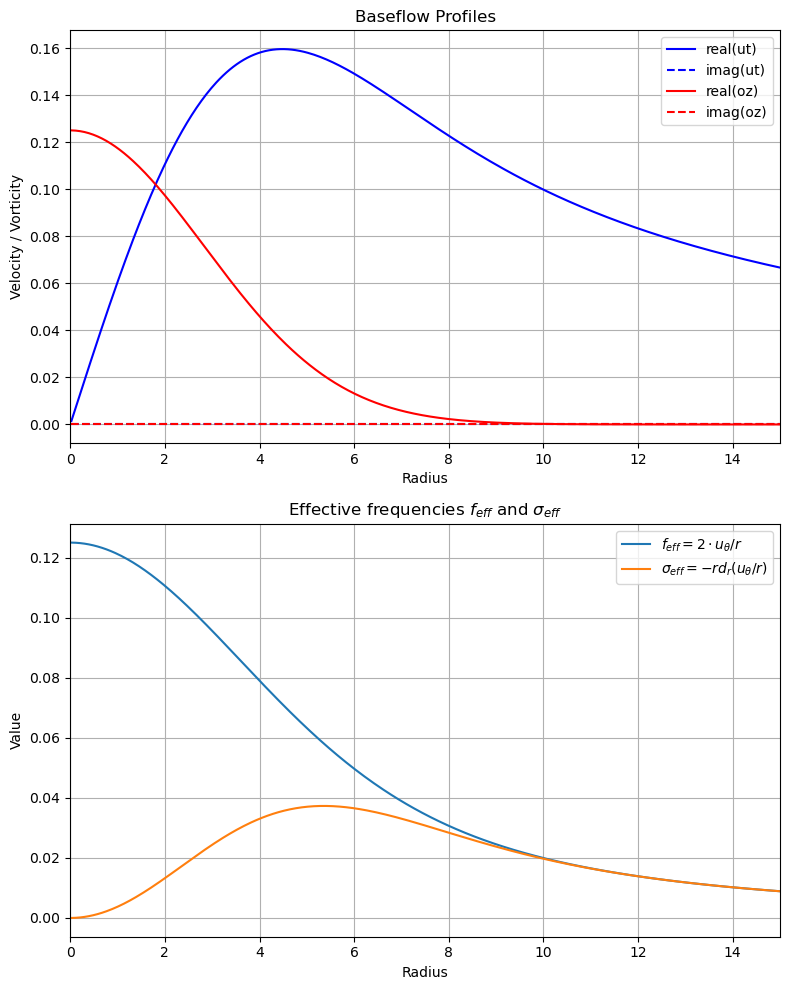

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

dir = '../../output'
filepath = os.path.join(dir, 'baseflow.dat')

# read baseflow.dat
# each line: radius(n), real(ut(n)), imag(ut(n)), real(oz(n)), imag(oz(n))
if not os.path.exists(filepath):
    print(f"Error: '{filepath}' not found.")
else:
    data = np.loadtxt(filepath)

    r = data[:, 0]
    ut = data[:, 1] + 1j * data[:, 2]
    oz = data[:, 3] + 1j * data[:, 4]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
    rlim = 15

    # Subplot 1: Azimuthal velocity and axial vorticity
    ax1.plot(r, ut.real, 'b-', label='real(ut)')
    ax1.plot(r, ut.imag, 'b--', label='imag(ut)')
    ax1.plot(r, oz.real, 'r-', label='real(oz)')
    ax1.plot(r, oz.imag, 'r--', label='imag(oz)')
    ax1.set_xlabel('Radius')
    ax1.set_ylabel('Velocity / Vorticity')
    ax1.set_title('Baseflow Profiles')
    ax1.set_xlim(0, rlim)
    ax1.legend()
    ax1.grid(True)

    # Subplot 2: f_eff and sigma_eff
    # handle r=0 case for omega = ut/r
    omega = np.zeros_like(ut)
    if r[0] == 0:
        # at r=0, omega = dut/dr, approximated by forward difference
        if len(r) > 1:
            omega[0] = (ut[1] - ut[0]) / (r[1] - r[0])
            omega[1:] = ut[1:] / r[1:]
        else:
            omega[0] = 0 # Or handle as an error/special case
    else:
        omega = ut / r

    f_eff = 2 * omega
    sigma_eff = -(oz - f_eff)

    ax2.plot(r, f_eff.real, label=r'$f_{eff} = 2\cdot u_\theta/r$')
    ax2.plot(r, sigma_eff.real, label=r'$\sigma_{eff} = -r d_r (u_\theta/r)$')
    ax2.set_xlabel('Radius')
    ax2.set_ylabel('Value')
    ax2.set_title(r'Effective frequencies $f_{eff}$ and $\sigma_{eff}$')
    ax2.set_xlim(0, rlim)
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()
